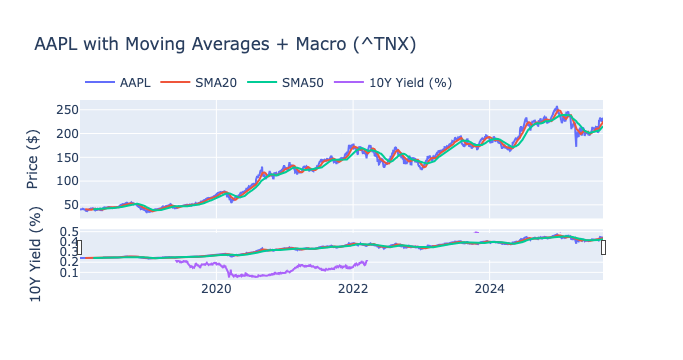

In [3]:
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots


ticker = "AAPL"
macro  = "^TNX"   
start  = "2018-01-01"

data = yf.download([ticker, macro], start=start, auto_adjust=True, progress=False)["Close"].dropna()

# TNX to precent
if macro in data.columns:
    data["TNX_pct"] = data[macro] / 10.0
else:
    raise ValueError("Macro ticker failed to download. Try '^VIX' or '^IRX'.")

price = data[ticker].rename("Price")

sma_fast = price.rolling(20).mean().rename("SMA20")   # 1 month of trading days
sma_slow = price.rolling(50).mean().rename("SMA50")   # 2.5 months of trading days

#layout
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.7, 0.3], vertical_spacing=0.06
)

# layout (price and MA)
fig.add_trace(go.Scatter(x=price.index, y=price, name=f"{ticker}", mode="lines"), row=1, col=1)
fig.add_trace(go.Scatter(x=sma_fast.index, y=sma_fast, name="SMA20", mode="lines"), row=1, col=1)
fig.add_trace(go.Scatter(x=sma_slow.index, y=sma_slow, name="SMA50", mode="lines"), row=1, col=1)

# layout(macro)
fig.add_trace(go.Scatter(x=data.index, y=data["TNX_pct"], name="10Y Yield (%)", mode="lines"), row=2, col=1)

# Cosmetics
fig.update_layout(
    title=f"{ticker} with Moving Averages + Macro ({macro})",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    hovermode="x unified",
)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="10Y Yield (%)", row=2, col=1)

# Range slider for dashboard feel
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))

fig.show()
